<a href="https://colab.research.google.com/github/aansheeagrwal/Machine-learning/blob/main/Rossman_Store_Sales_Prediction_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
!pip install numpy pandas matplotlib plotly seaborn --quiet


In [11]:
!pip install jovian opendatasets scikit-learn --upgrade --quiet

In [12]:
import os
import jovian
import matplotlib
import opendatasets as od
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
%matplotlib inline

sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [13]:
od.download('https://www.kaggle.com/c/rossmann-store-sales')

Skipping, found downloaded files in "./rossmann-store-sales" (use force=True to force download)


In [14]:
os.listdir('rossmann-store-sales')

['train.csv', 'sample_submission.csv', 'test.csv', 'store.csv']

In [15]:
ross_df = pd.read_csv('./rossmann-store-sales/train.csv', low_memory=False)

In [16]:
ross_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1
...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1


In [17]:
store_df = pd.read_csv('./rossmann-store-sales/store.csv')

In [18]:
store_df

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1110,1111,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1111,1112,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [19]:
merged_df = ross_df.merge(store_df, how='left', on='Store')
merged_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1017205,1112,2,2013-01-01,0,0,0,0,a,1,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1017206,1113,2,2013-01-01,0,0,0,0,a,1,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1017207,1114,2,2013-01-01,0,0,0,0,a,1,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [20]:
merged_df.shape

(1017209, 18)

In [21]:
test_df = pd.read_csv('./rossmann-store-sales/test.csv')

In [22]:
merged_test_df = test_df.merge(store_df, how='left', on='Store')
merged_test_df

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,1,4,2015-09-17,1.0,1,0,0,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,3,4,2015-09-17,1.0,1,0,0,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
2,3,7,4,2015-09-17,1.0,1,0,0,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN
3,4,8,4,2015-09-17,1.0,1,0,0,a,a,7520.0,10.0,2014.0,0,NaN,NaN,NaN
4,5,9,4,2015-09-17,1.0,1,0,0,a,c,2030.0,8.0,2000.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41083,41084,1111,6,2015-08-01,1.0,0,0,0,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
41084,41085,1112,6,2015-08-01,1.0,0,0,0,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
41085,41086,1113,6,2015-08-01,1.0,0,0,0,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
41086,41087,1114,6,2015-08-01,1.0,0,0,0,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [23]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  object 
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  object 
 10  Assortment                 1017209 non-null  object 
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionO

In [24]:
round(merged_df.describe().T,2)


,count,mean,std,min,25%,50%,75%,max
Store,1017209.0,558.43,321.91,1.0,280.0,558.0,838.0,1115.0
DayOfWeek,1017209.0,4.00,2.00,1.0,2.0,4.0,6.0,7.0
Sales,1017209.0,5773.82,3849.93,0.0,3727.0,5744.0,7856.0,41551.0
Customers,1017209.0,633.15,464.41,0.0,405.0,609.0,837.0,7388.0
Open,1017209.0,0.83,0.38,0.0,1.0,1.0,1.0,1.0
Promo,1017209.0,0.38,0.49,0.0,0.0,0.0,1.0,1.0
SchoolHoliday,1017209.0,0.18,0.38,0.0,0.0,0.0,0.0,1.0
CompetitionDistance,1014567.0,5430.09,7715.32,20.0,710.0,2330.0,6890.0,75860.0
CompetitionOpenSinceMonth,693861.0,7.22,3.21,1.0,4.0,8.0,10.0,12.0
CompetitionOpenSinceYear,693861.0,2008.69,5.99,1900.0,2006.0,2010.0,2013.0,2015.0


In [25]:
merged_df.duplicated().sum()

np.int64(0)

In [26]:
merged_df['Date'] = pd.to_datetime(merged_df['Date'])

In [27]:
merged_test_df['Date'] = pd.to_datetime(merged_test_df.Date)

In [28]:
merged_df.Date.min(), merged_df.Date.max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2015-07-31 00:00:00'))

In [29]:
merged_test_df.Date.min(), merged_test_df.Date.max()

(Timestamp('2015-08-01 00:00:00'), Timestamp('2015-09-17 00:00:00'))

<Axes: xlabel='Sales', ylabel='Count'>

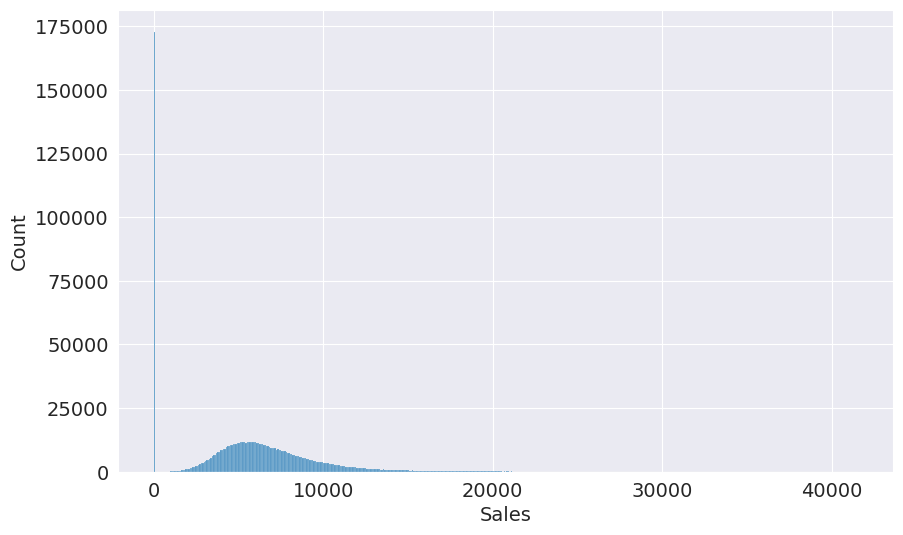

In [30]:
sns.histplot(data=merged_df, x='Sales')

In [31]:
merged_df.Open.value_counts()

,count
Open,
1,844392
0,172817


In [32]:
merged_df.Sales.value_counts()[0]

np.int64(172871)

In [ ]:
merged_df = merged_df[merged_df.Open==1].copy()

<Axes: xlabel='Sales', ylabel='Count'>

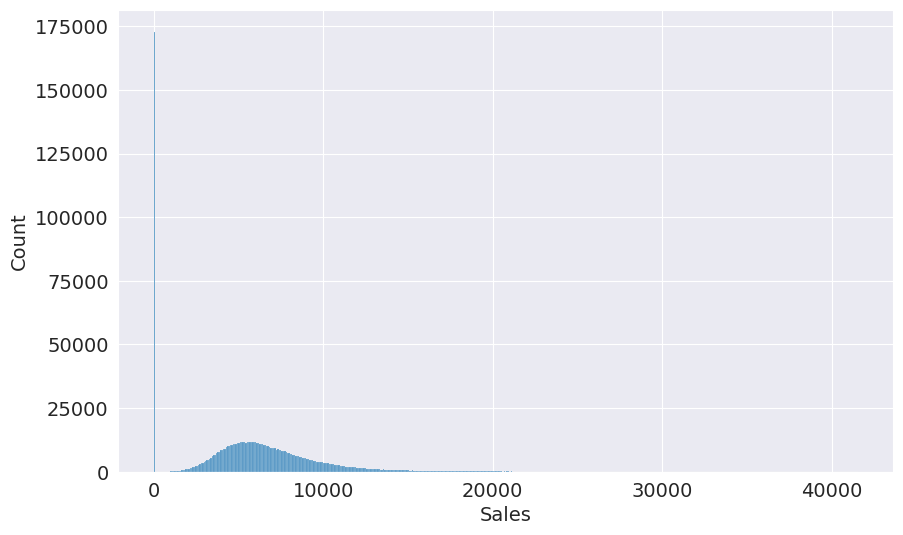

In [33]:
sns.histplot(data=merged_df, x='Sales')

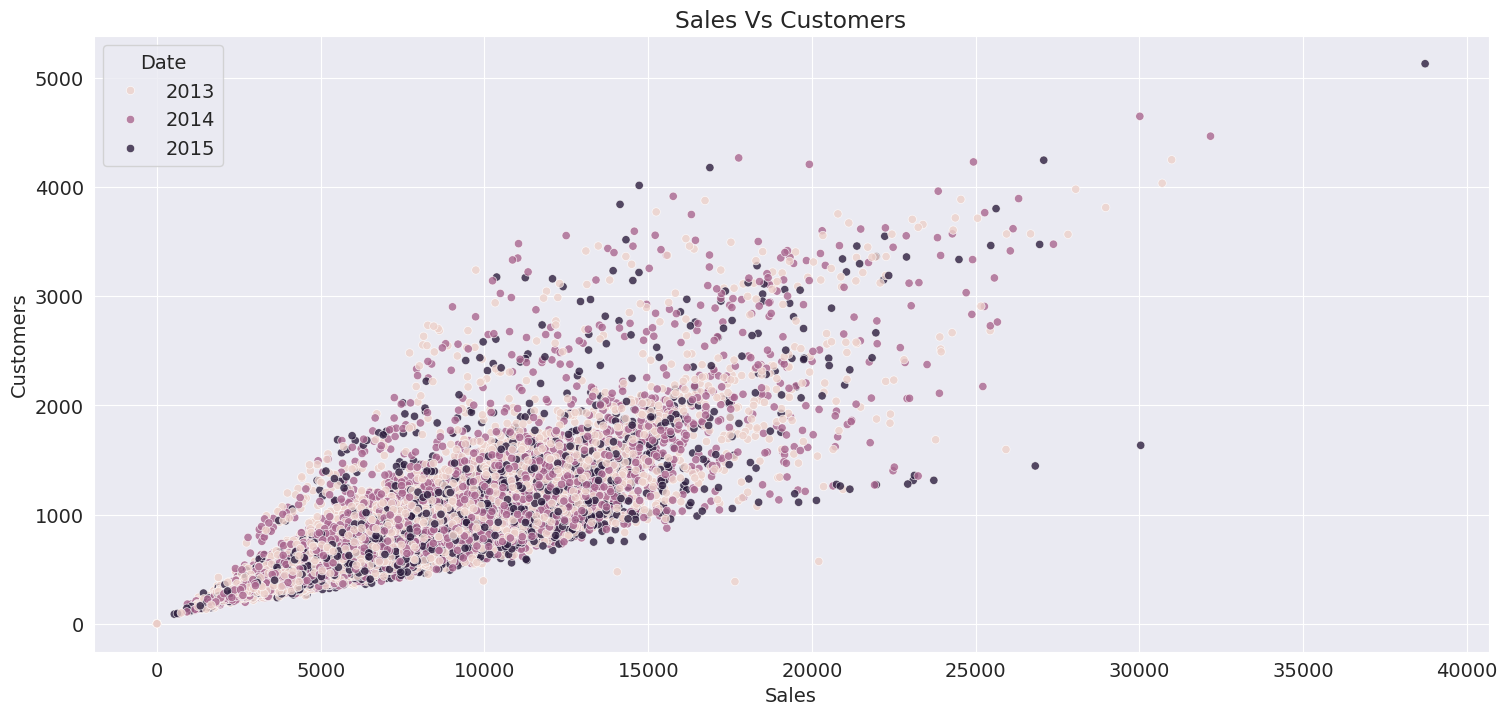

In [34]:
plt.figure(figsize=(18,8))
temp_df = merged_df.sample(40000)
sns.scatterplot(x=temp_df.Sales, y=temp_df.Customers, hue=temp_df.Date.dt.year, alpha=0.8)
plt.title("Sales Vs Customers")
plt.show()

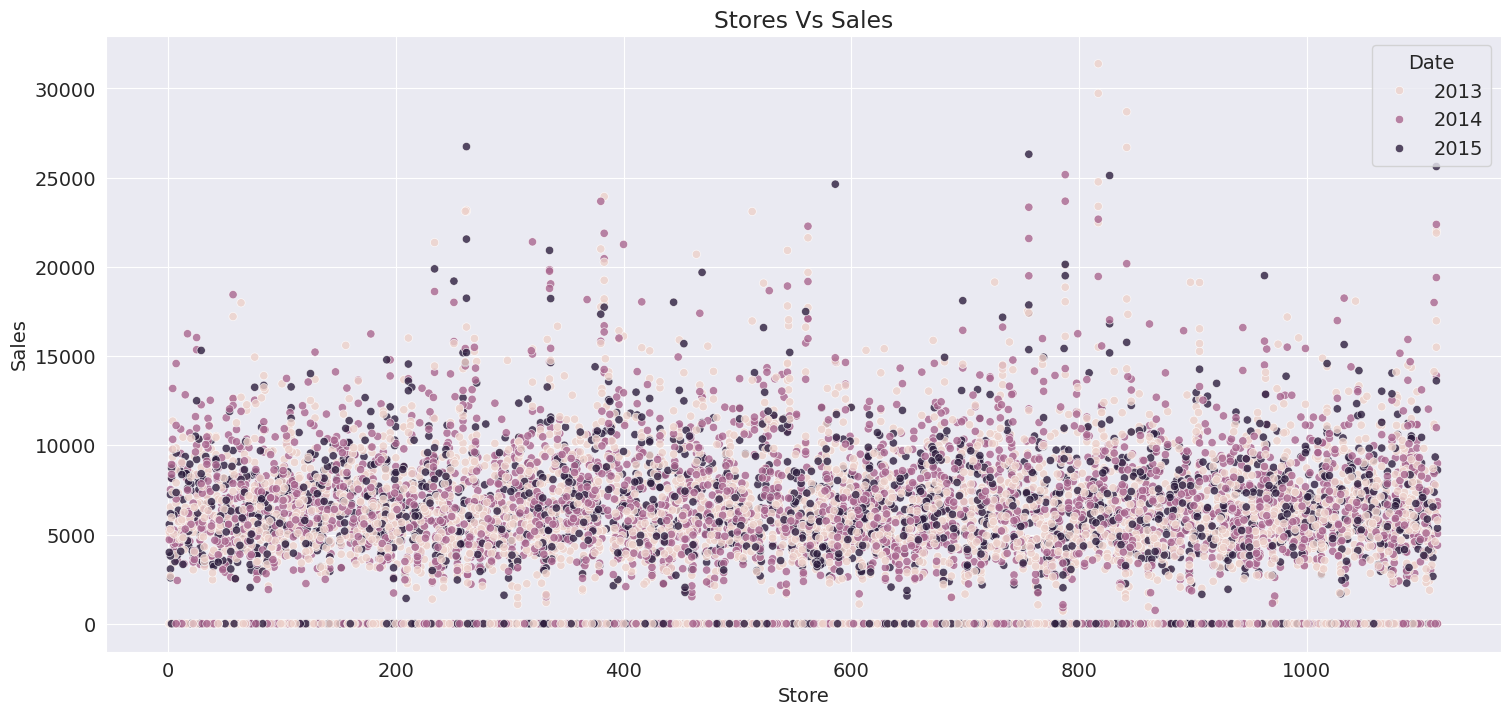

In [35]:
plt.figure(figsize=(18,8))
temp_df = merged_df.sample(10000)
sns.scatterplot(x=temp_df.Store, y=temp_df.Sales, hue=temp_df.Date.dt.year, alpha=0.8)
plt.title("Stores Vs Sales")
plt.show()

<Axes: xlabel='DayOfWeek', ylabel='Sales'>

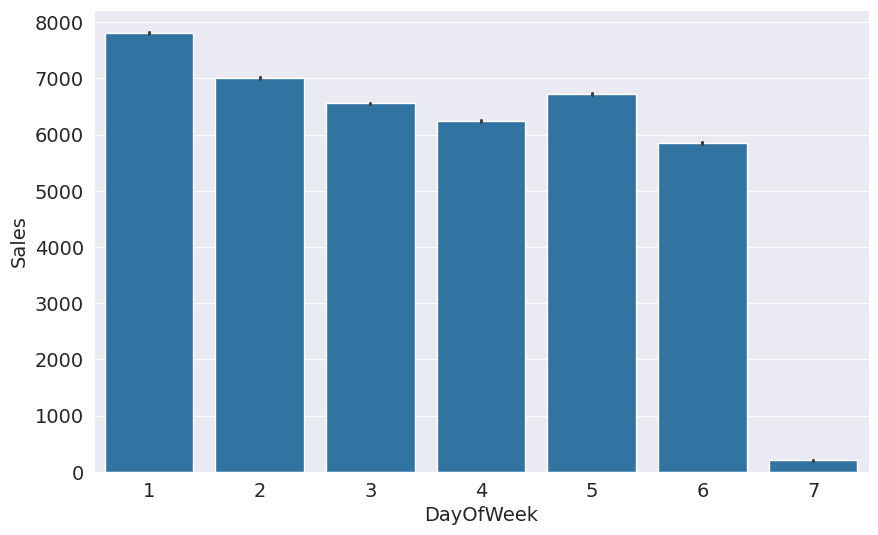

In [36]:
sns.barplot(data=merged_df, x='DayOfWeek', y='Sales')


<Axes: xlabel='Promo', ylabel='Sales'>

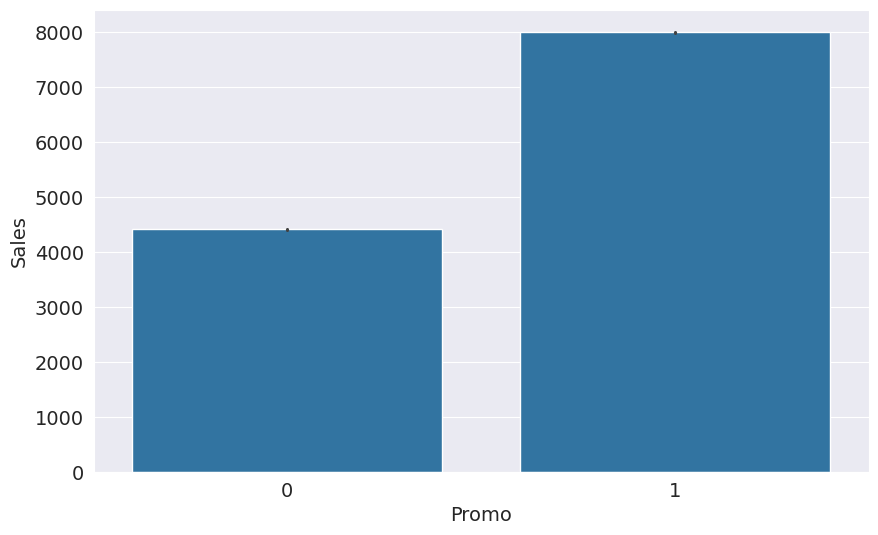

In [37]:
sns.barplot(data=merged_df, x='Promo', y='Sales')


In [38]:
merged_df.select_dtypes(include='number').corr()['Sales'].sort_values(ascending=False)


,Sales
Sales,1.000000
Customers,0.894711
Open,0.678472
Promo,0.452345
SchoolHoliday,0.085124
Promo2SinceWeek,0.059558
CompetitionOpenSinceYear,0.012659
Store,0.005126
CompetitionDistance,-0.019229
Promo2SinceYear,-0.021127


In [39]:
merged_df['Day'] = merged_df.Date.dt.day
merged_df['Month'] = merged_df.Date.dt.month
merged_df['Year'] = merged_df.Date.dt.year

In [40]:
merged_test_df['Day'] = merged_test_df.Date.dt.day
merged_test_df['Month'] = merged_test_df.Date.dt.month
merged_test_df['Year'] = merged_test_df.Date.dt.year

<Axes: xlabel='Year', ylabel='Sales'>

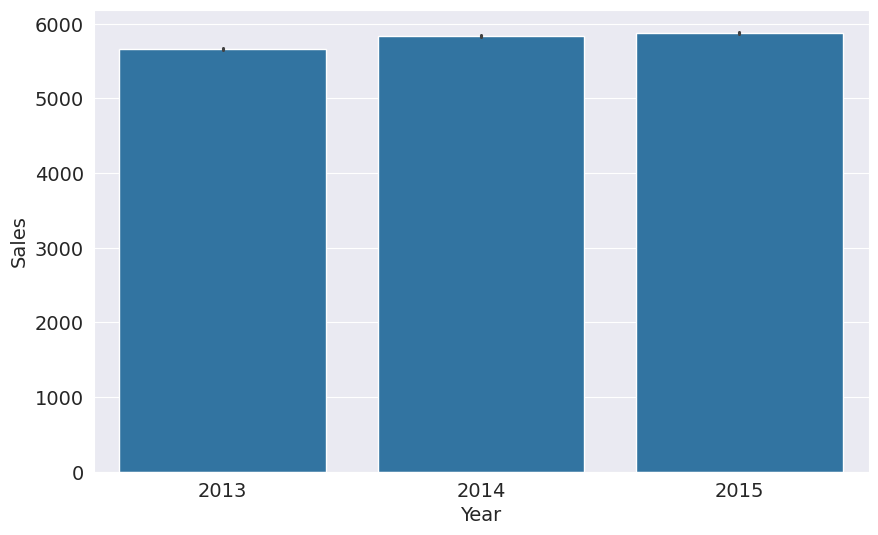

In [41]:
sns.barplot(data=merged_df, x='Year', y='Sales')


<Axes: xlabel='Month', ylabel='Sales'>

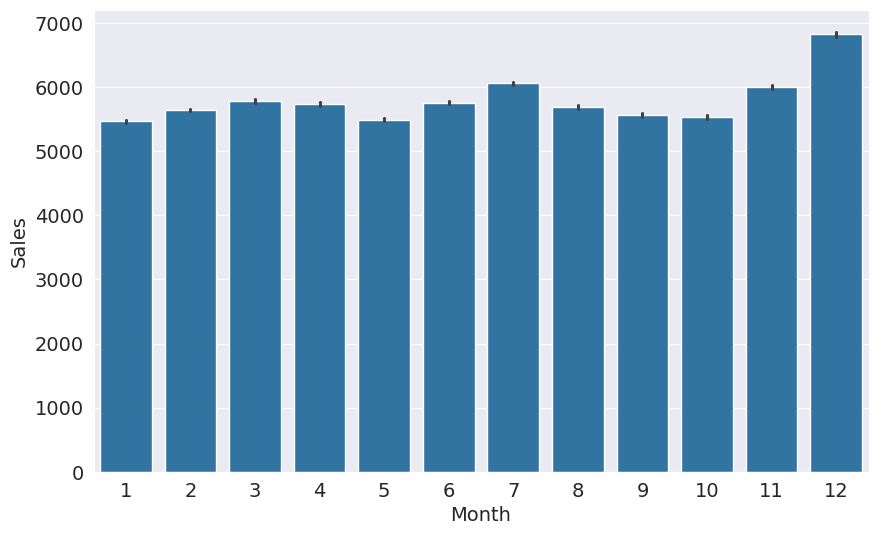

In [42]:
sns.barplot(data=merged_df, x='Month', y='Sales')

In [43]:
len(merged_df)

1017209

In [45]:
train_size = int(.75 * len(merged_df))
train_size

762906

In [46]:
sorted_df = merged_df.sort_values('Date')
train_df, val_df = sorted_df[:train_size], sorted_df[train_size:]

In [47]:
len(train_df), len(val_df)

(762906, 254303)

In [48]:
train_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Day,Month,Year
1017208,1115,2,2013-01-01,0,0,0,0,a,1,d,...,5350.0,NaN,NaN,1,22.0,2012.0,"Mar,Jun,Sept,Dec",1,1,2013
1016473,379,2,2013-01-01,0,0,0,0,a,1,d,...,6630.0,NaN,NaN,0,NaN,NaN,NaN,1,1,2013
1016472,378,2,2013-01-01,0,0,0,0,a,1,a,...,2140.0,8.0,2012.0,0,NaN,NaN,NaN,1,1,2013
1016471,377,2,2013-01-01,0,0,0,0,a,1,a,...,100.0,6.0,2010.0,1,18.0,2010.0,"Feb,May,Aug,Nov",1,1,2013
1016470,376,2,2013-01-01,0,0,0,0,a,1,a,...,160.0,8.0,2012.0,0,NaN,NaN,NaN,1,1,2013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
254627,577,5,2014-12-12,3993,448,1,0,0,0,a,...,2270.0,NaN,NaN,1,35.0,2012.0,"Mar,Jun,Sept,Dec",12,12,2014
254626,576,5,2014-12-12,5741,793,1,0,0,0,c,...,50.0,11.0,2006.0,0,NaN,NaN,NaN,12,12,2014
254625,574,5,2014-12-12,9359,678,1,0,0,0,d,...,4400.0,NaN,NaN,0,NaN,NaN,NaN,12,12,2014
254624,572,5,2014-12-12,6737,537,1,0,0,0,d,...,9230.0,4.0,2004.0,1,37.0,2009.0,"Jan,Apr,Jul,Oct",12,12,2014


In [49]:
train_df.Date.min(), train_df.Date.max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2014-12-12 00:00:00'))

In [50]:
val_df.Date.min(), val_df.Date.max()

(Timestamp('2014-12-12 00:00:00'), Timestamp('2015-07-31 00:00:00'))

In [51]:
merged_test_df.Date.min(), merged_test_df.Date.max()

(Timestamp('2015-08-01 00:00:00'), Timestamp('2015-09-17 00:00:00'))

In [52]:
train_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Day,Month,Year
1017208,1115,2,2013-01-01,0,0,0,0,a,1,d,...,5350.0,NaN,NaN,1,22.0,2012.0,"Mar,Jun,Sept,Dec",1,1,2013
1016473,379,2,2013-01-01,0,0,0,0,a,1,d,...,6630.0,NaN,NaN,0,NaN,NaN,NaN,1,1,2013
1016472,378,2,2013-01-01,0,0,0,0,a,1,a,...,2140.0,8.0,2012.0,0,NaN,NaN,NaN,1,1,2013
1016471,377,2,2013-01-01,0,0,0,0,a,1,a,...,100.0,6.0,2010.0,1,18.0,2010.0,"Feb,May,Aug,Nov",1,1,2013
1016470,376,2,2013-01-01,0,0,0,0,a,1,a,...,160.0,8.0,2012.0,0,NaN,NaN,NaN,1,1,2013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
254627,577,5,2014-12-12,3993,448,1,0,0,0,a,...,2270.0,NaN,NaN,1,35.0,2012.0,"Mar,Jun,Sept,Dec",12,12,2014
254626,576,5,2014-12-12,5741,793,1,0,0,0,c,...,50.0,11.0,2006.0,0,NaN,NaN,NaN,12,12,2014
254625,574,5,2014-12-12,9359,678,1,0,0,0,d,...,4400.0,NaN,NaN,0,NaN,NaN,NaN,12,12,2014
254624,572,5,2014-12-12,6737,537,1,0,0,0,d,...,9230.0,4.0,2004.0,1,37.0,2009.0,"Jan,Apr,Jul,Oct",12,12,2014


In [53]:
train_df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval', 'Day', 'Month', 'Year'],
      dtype='object')

In [54]:
input_cols = ['Store', 'DayOfWeek', 'Promo', 'StateHoliday', 'StoreType', 'Assortment', 'Day', 'Month', 'Year']

In [55]:
target_col = 'Sales'


In [56]:
merged_df[input_cols].nunique()


,0
Store,1115
DayOfWeek,7
Promo,2
StateHoliday,4
StoreType,4
Assortment,3
Day,31
Month,12
Year,3


In [57]:
train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()

In [58]:
val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_col].copy()

In [59]:
test_inputs = merged_test_df[input_cols].copy()
# Test data does not have targets

In [60]:
numeric_cols = ['Store', 'Day', 'Month', 'Year']
categorical_cols = ['DayOfWeek', 'Promo', 'StateHoliday', 'StoreType', 'Assortment']

In [61]:
from sklearn.impute import SimpleImputer

In [62]:
imputer = SimpleImputer(strategy='mean').fit(train_inputs[numeric_cols])

In [63]:
train_inputs[numeric_cols] = imputer.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = imputer.transform(val_inputs[numeric_cols])
test_inputs[numeric_cols] = imputer.transform(test_inputs[numeric_cols])

In [64]:
from sklearn.preprocessing import OneHotEncoder

In [70]:
# Ensure columns are string-typed and nulls are handled
train_inputs[categorical_cols] = train_inputs[categorical_cols].astype(str).fillna("missing")
val_inputs[categorical_cols] = val_inputs[categorical_cols].astype(str).fillna("missing")
test_inputs[categorical_cols] = test_inputs[categorical_cols].astype(str).fillna("missing")

# Fit the encoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.fit(train_inputs[categorical_cols])

# Get encoded column names
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))


In [71]:
encoder.fit(train_inputs[categorical_cols])


OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [72]:
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))

train_encoded = pd.DataFrame(
    encoder.transform(train_inputs[categorical_cols]),
    columns=encoded_cols,
    index=train_inputs.index
)

val_encoded = pd.DataFrame(
    encoder.transform(val_inputs[categorical_cols]),
    columns=encoded_cols,
    index=val_inputs.index
)

test_encoded = pd.DataFrame(
    encoder.transform(test_inputs[categorical_cols]),
    columns=encoded_cols,
    index=test_inputs.index
)


In [73]:
train_inputs = pd.concat([train_inputs.drop(columns=categorical_cols), train_encoded], axis=1)
val_inputs = pd.concat([val_inputs.drop(columns=categorical_cols), val_encoded], axis=1)
test_inputs = pd.concat([test_inputs.drop(columns=categorical_cols), test_encoded], axis=1)


In [74]:
encoded_cols

['DayOfWeek_1',
 'DayOfWeek_2',
 'DayOfWeek_3',
 'DayOfWeek_4',
 'DayOfWeek_5',
 'DayOfWeek_6',
 'DayOfWeek_7',
 'Promo_0',
 'Promo_1',
 'StateHoliday_0',
 'StateHoliday_a',
 'StateHoliday_b',
 'StateHoliday_c',
 'StoreType_a',
 'StoreType_b',
 'StoreType_c',
 'StoreType_d',
 'Assortment_a',
 'Assortment_b',
 'Assortment_c']

In [75]:
X_train = train_inputs[numeric_cols + encoded_cols]
X_val = val_inputs[numeric_cols + encoded_cols]
X_test = test_inputs[numeric_cols + encoded_cols]


In [76]:
def return_mean(inputs):
    return np.full(len(inputs), merged_df.Sales.mean())

In [77]:
train_preds = return_mean(X_train)

In [78]:
train_preds

array([5773.81897231, 5773.81897231, 5773.81897231, ..., 5773.81897231,
       5773.81897231, 5773.81897231])

In [79]:
from sklearn.metrics import mean_squared_error

In [80]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Assuming train_preds and train_targets are defined
mse = mean_squared_error(train_preds, train_targets)
rmse = np.sqrt(mse)
print("RMSE:", rmse)




RMSE: 3806.4287422638695


In [81]:
from sklearn.metrics import mean_squared_error
import numpy as np

mse = mean_squared_error(return_mean(X_val), val_targets)
rmse = np.sqrt(mse)
print("RMSE:", rmse)


RMSE: 3977.5576294933835


In [82]:
def guess_random(inputs):
    lo, hi = merged_df.Sales.min(), merged_df.Sales.max()
    return np.random.random(len(inputs)) * (hi - lo) + lo

In [83]:
train_preds = guess_random(X_train)
train_preds

array([ 3341.54226609, 10552.03034763, 29545.38525303, ...,
       21852.54547133, 26982.81247997, 16986.16220889])

In [84]:
from sklearn.metrics import mean_squared_error
import numpy as np

mse = mean_squared_error(train_preds, train_targets)
rmse = np.sqrt(mse)
print("RMSE:", rmse)


RMSE: 19613.41717910805


In [85]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Get predictions from guess_random
val_preds = guess_random(X_val)

# Compute RMSE manually
mse = mean_squared_error(val_targets, val_preds)
rmse = np.sqrt(mse)
print("RMSE:", rmse)


RMSE: 19495.464762954405


In [86]:
from sklearn.linear_model import LinearRegression

In [87]:
linreg = LinearRegression()

In [88]:
linreg.fit(X_train, train_targets)

LinearRegression()

In [89]:
train_preds = linreg.predict(X_train)
train_preds

array([ -558.34799635, -1237.96262026,  -307.28944255, ...,
        5648.48610934,  6275.43919316,  5951.84941772])

In [90]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Compute RMSE manually
mse = mean_squared_error(train_targets, train_preds)
rmse = np.sqrt(mse)
print("Train RMSE:", rmse)


Train RMSE: 2566.0017837491328


In [91]:
val_preds = linreg.predict(X_val)
val_preds

array([5951.77806062, 6275.15376475, 5835.10972782, ..., 7645.98092482,
       8272.64858024, 7779.80028901])

In [92]:
from sklearn.metrics import mean_squared_error
import numpy as np

mse = mean_squared_error(val_targets, val_preds)
rmse = np.sqrt(mse)
print("Validation RMSE:", rmse)


Validation RMSE: 2618.3441471038122


In [93]:
def try_model(model):
    # Fit the model
    model.fit(X_train, train_targets)

    # Generate predictions
    train_preds = model.predict(X_train)
    val_preds = model.predict(X_val)

    # Compute RMSE
    train_rmse = mean_squared_error(train_targets, train_preds, squared=False)
    val_rmse = mean_squared_error(val_targets, val_preds, squared=False)
    return train_rmse, val_rmse

In [94]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, SGDRegressor

In [100]:
print(train_inputs.columns)


Index(['Store', 'Day', 'Month', 'Year', 'DayOfWeek_1', 'DayOfWeek_2',
       'DayOfWeek_3', 'DayOfWeek_4', 'DayOfWeek_5', 'DayOfWeek_6',
       'DayOfWeek_7', 'Promo_0', 'Promo_1', 'StateHoliday_0', 'StateHoliday_a',
       'StateHoliday_b', 'StateHoliday_c', 'StoreType_a', 'StoreType_b',
       'StoreType_c', 'StoreType_d', 'Assortment_a', 'Assortment_b',
       'Assortment_c'],
      dtype='object')


In [103]:
from sklearn.metrics import mean_squared_error
import numpy as np

def try_model(model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train)
    train_preds = model.predict(X_train)
    val_preds = model.predict(X_val)
    train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
    val_rmse = np.sqrt(mean_squared_error(y_val, val_preds))
    return train_rmse, val_rmse


In [104]:
print(try_model(LinearRegression(), train_inputs, train_targets, val_inputs, val_targets))


(np.float64(2566.0017837491328), np.float64(2618.3441471038122))


In [108]:
print(try_model(Ridge(), train_inputs, train_targets, val_inputs, val_targets))


(np.float64(2566.0017867480447), np.float64(2618.3461397373044))


In [109]:
print(try_model(Lasso(), train_inputs, train_targets, val_inputs, val_targets))


(np.float64(2566.2638669464895), np.float64(2619.1372521799244))


In [111]:
print(try_model(SGDRegressor(), train_inputs, train_targets, val_inputs, val_targets))


(np.float64(132847400245936.92), np.float64(132911451275701.75))


In [112]:
print(try_model(ElasticNet(), train_inputs, train_targets, val_inputs, val_targets))


(np.float64(3242.443996412866), np.float64(3411.288113000505))


In [113]:
from sklearn.tree import DecisionTreeRegressor,plot_tree


In [115]:
print(try_model(DecisionTreeRegressor(random_state=42), train_inputs, train_targets, val_inputs, val_targets))



(np.float64(0.0), np.float64(1481.6430381000896))


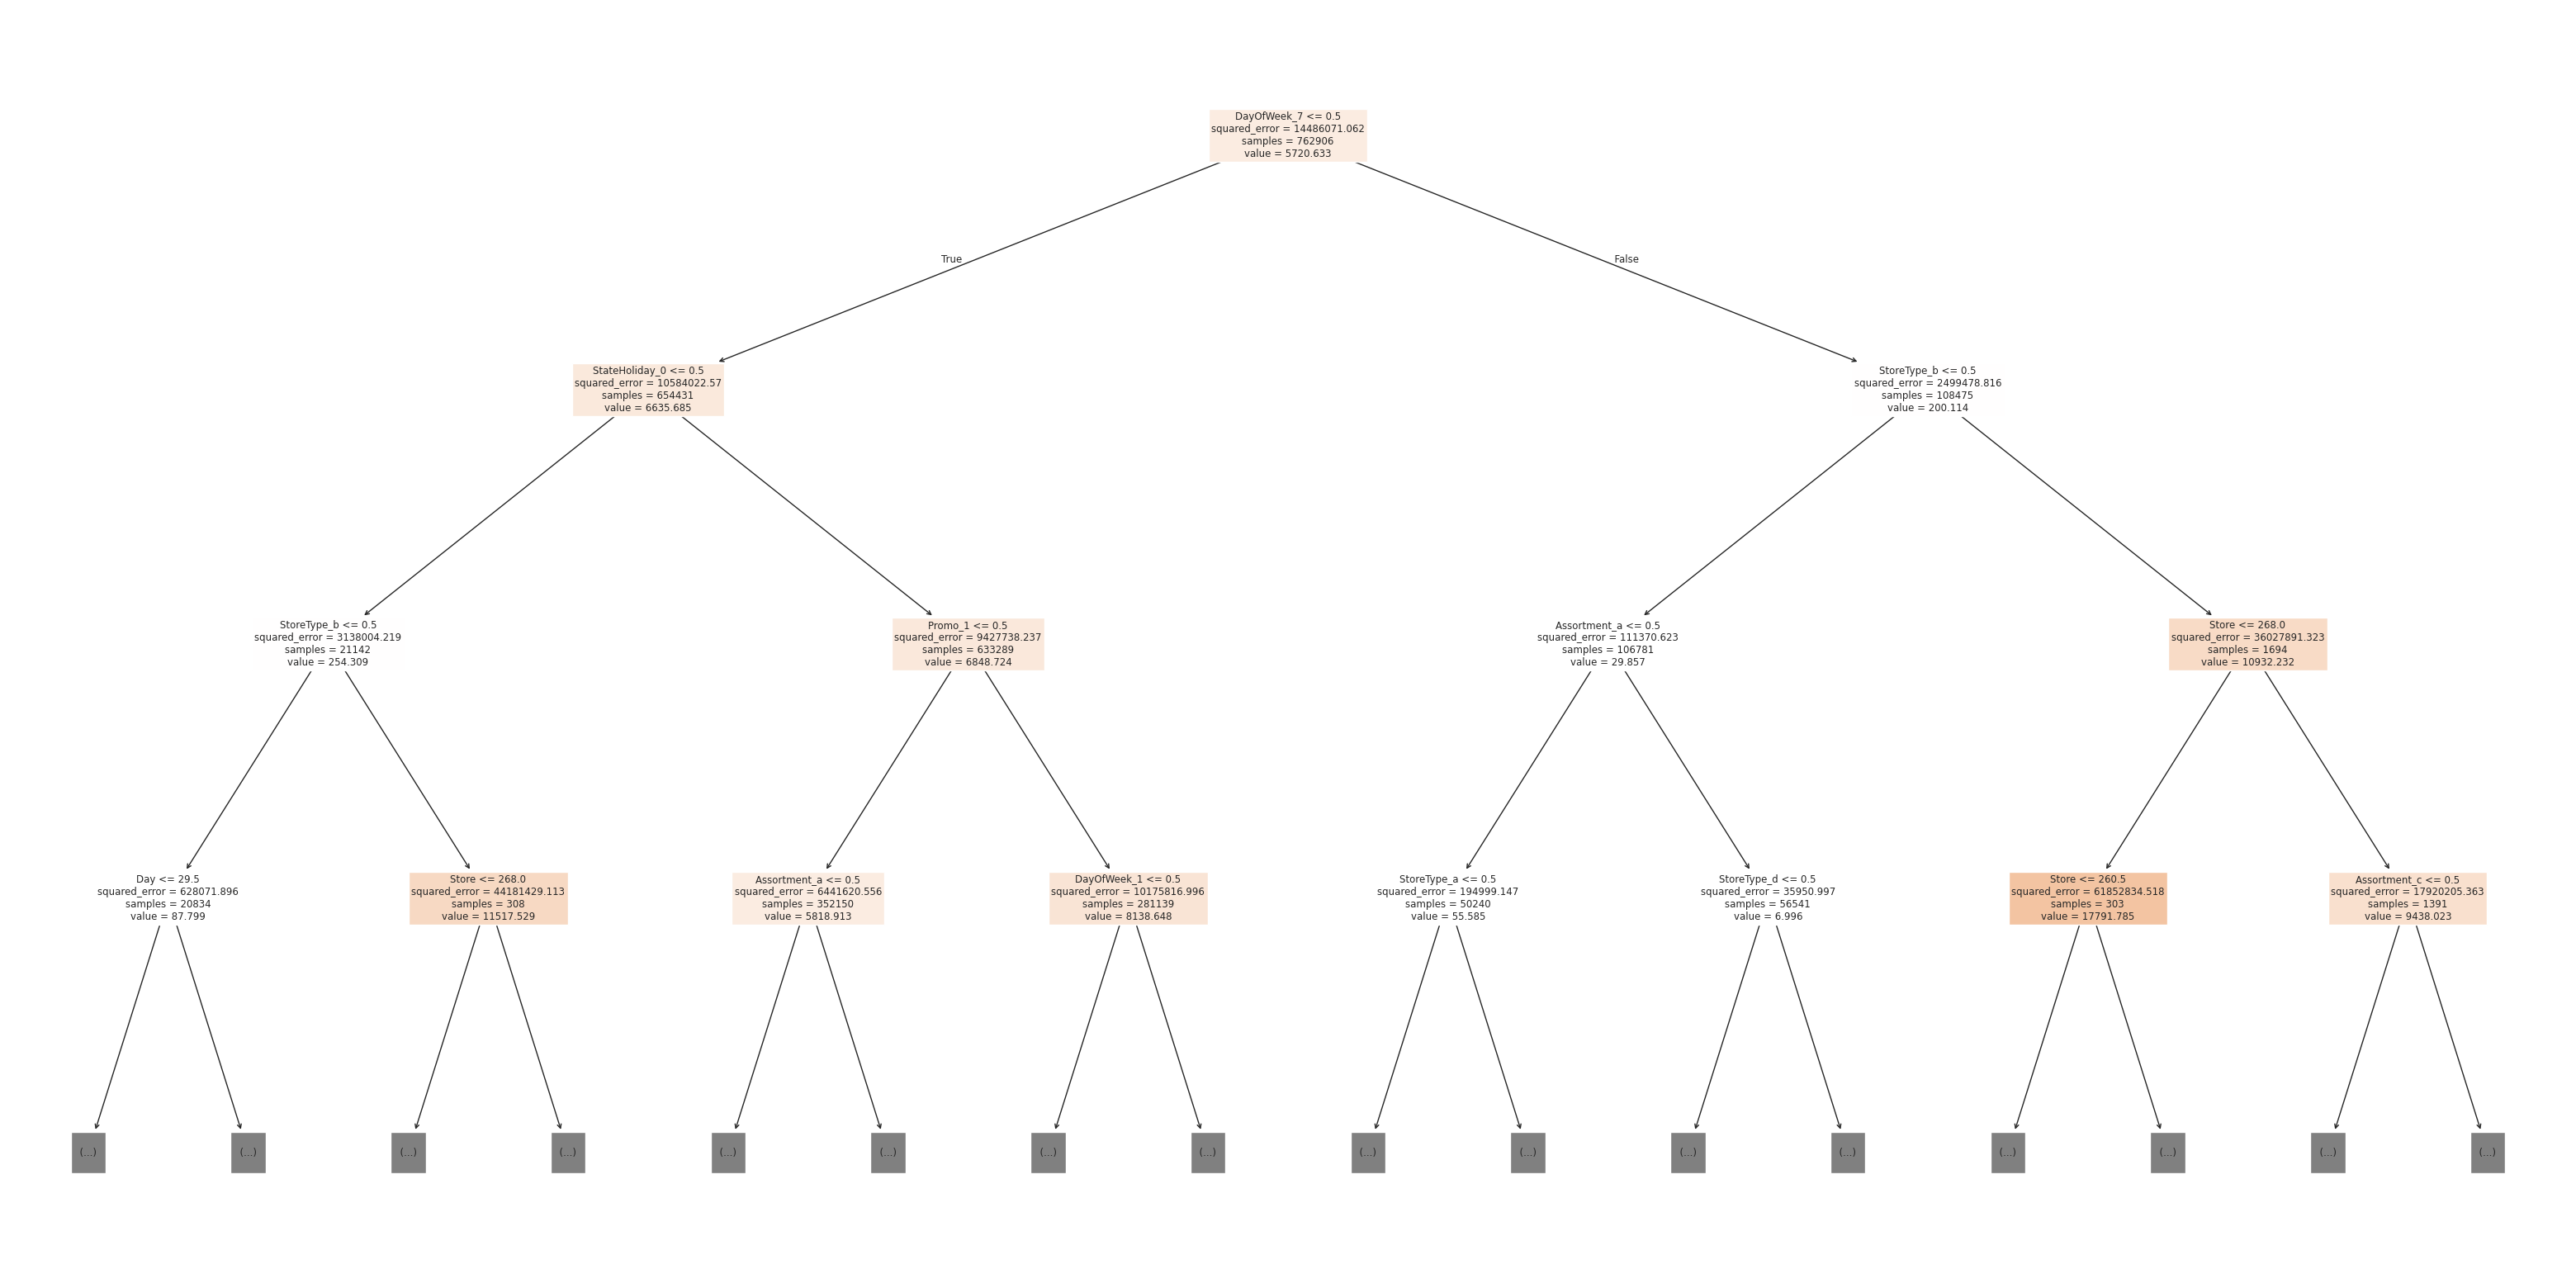

In [119]:
# Fit the model first
tree.fit(train_inputs, train_targets)

# Now plot the tree
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(40,20))
plot_tree(tree, max_depth=3, filled=True, feature_names=numeric_cols + encoded_cols)
plt.show()


In [120]:
from sklearn.ensemble import RandomForestRegressor


In [122]:
print(try_model(RandomForestRegressor(random_state=42, n_jobs=-1, n_estimators=20), train_inputs, train_targets, val_inputs, val_targets))


(np.float64(484.25653396491794), np.float64(1324.7876673241522))


In [125]:
# Define and fit the model
rf = RandomForestRegressor(random_state=42, n_jobs=-1, n_estimators=20)
rf.fit(train_inputs, train_targets)

# Now you can access feature importances
print(rf.feature_importances_)


[3.38724515e-01 2.76431035e-02 2.82558889e-02 5.85263754e-03
 1.82769997e-02 2.36005583e-03 1.34464265e-03 1.20761984e-03
 3.11612260e-03 3.69703445e-03 3.48418801e-01 4.17666514e-02
 3.42576404e-02 8.06334501e-02 5.26731144e-06 1.81815413e-06
 1.33879579e-05 7.31975181e-03 2.89912445e-02 5.96687949e-03
 7.97494190e-03 6.08902055e-03 3.34314244e-03 4.73938287e-03]


In [126]:
importance_df = pd.DataFrame({
    'feature': numeric_cols+encoded_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)
importance_df.head(10)


,feature,importance
10,DayOfWeek_7,0.348419
0,Store,0.338725
13,StateHoliday_0,0.080633
11,Promo_0,0.041767
12,Promo_1,0.034258
18,StoreType_b,0.028991
2,Month,0.028256
1,Day,0.027643
4,DayOfWeek_1,0.018277
20,StoreType_d,0.007975


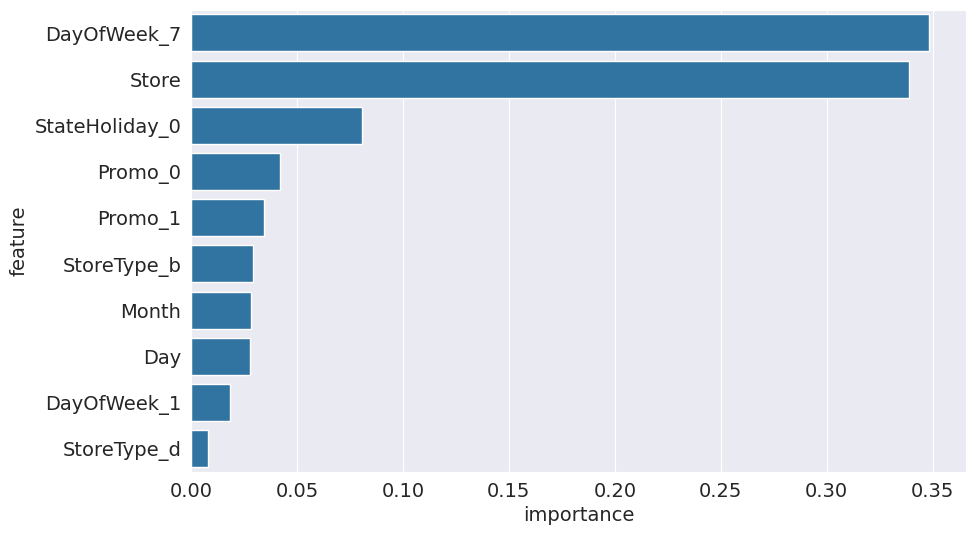

In [127]:
sns.barplot(data=importance_df.head(10), x='importance', y='feature');


In [128]:
def predict_input(model, single_input):
    if single_input['Open'] == 0:
        return 0.
    input_df = pd.DataFrame([single_input])
    input_df['Date'] = pd.to_datetime(input_df['Date'], errors='coerce')
    input_df['day'] = input_df.Date.dt.day
    input_df['month'] = input_df.Date.dt.month
    input_df['year'] = input_df.Date.dt.year
    input_df[categorical_cols] = input_df[categorical_cols].astype(str)
    input_df[numeric_cols] = imputer.transform(input_df[numeric_cols])
    input_df[numeric_cols] = scaler.transform(input_df[numeric_cols])
    input_df[encoded_cols] = encoder.transform(input_df[categorical_cols])
    X_input = input_df[numeric_cols + encoded_cols]
    pred = model.predict(X_input)[0]
    return pred

In [132]:
print(numeric_cols + encoded_cols)


['Store', 'Day', 'Month', 'Year', 'DayOfWeek_1', 'DayOfWeek_2', 'DayOfWeek_3', 'DayOfWeek_4', 'DayOfWeek_5', 'DayOfWeek_6', 'DayOfWeek_7', 'Promo_0', 'Promo_1', 'StateHoliday_0', 'StateHoliday_a', 'StateHoliday_b', 'StateHoliday_c', 'StoreType_a', 'StoreType_b', 'StoreType_c', 'StoreType_d', 'Assortment_a', 'Assortment_b', 'Assortment_c']


In [134]:
sample_input = pd.DataFrame({
    'Store': [1],
    'Day': [15],
    'Month': [5],
    'Year': [2020],
    'DayOfWeek_1': [0],
    'DayOfWeek_2': [0],
    'DayOfWeek_3': [0],
    'DayOfWeek_4': [0],
    'DayOfWeek_5': [1],  # Assuming it's a Friday
    'DayOfWeek_6': [0],
    'DayOfWeek_7': [0],
    'Promo_0': [1],
    'Promo_1': [0],
    'StateHoliday_0': [1],
    'StateHoliday_a': [0],
    'StateHoliday_b': [0],
    'StateHoliday_c': [0],
    'StoreType_a': [1],
    'StoreType_b': [0],
    'StoreType_c': [0],
    'StoreType_d': [0],
    'Assortment_a': [0],
    'Assortment_b': [1],
    'Assortment_c': [0]
})

# Make sure the sample_input has the same columns as the training data
sample_input = sample_input[numeric_cols + encoded_cols]

# Predict
rf.predict(sample_input)


array([7777.35])

In [135]:
X_test

,Store,Day,Month,Year,DayOfWeek_1,DayOfWeek_2,DayOfWeek_3,DayOfWeek_4,DayOfWeek_5,DayOfWeek_6,...,StateHoliday_a,StateHoliday_b,StateHoliday_c,StoreType_a,StoreType_b,StoreType_c,StoreType_d,Assortment_a,Assortment_b,Assortment_c
0,1.0,17.0,9.0,2015.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,3.0,17.0,9.0,2015.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,7.0,17.0,9.0,2015.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,8.0,17.0,9.0,2015.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,9.0,17.0,9.0,2015.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41083,1111.0,1.0,8.0,2015.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
41084,1112.0,1.0,8.0,2015.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
41085,1113.0,1.0,8.0,2015.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
41086,1114.0,1.0,8.0,2015.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [144]:
test_preds

array([ 4453.  ,  7581.35,  9168.3 , ...,  6027.8 , 20780.  ,  6932.3 ])

In [137]:
test_preds = rf.predict(X_test)
test_preds

array([ 4453.  ,  7581.35,  9168.3 , ...,  6027.8 , 20780.  ,  6932.3 ])

In [138]:
submission_df = pd.read_csv('./rossmann-store-sales/sample_submission.csv')

In [143]:
submission_df

,Id,Sales
0,1,4453.00
1,2,7581.35
2,3,9168.30
3,4,6694.15
4,5,6511.65
...,...,...
41083,41084,3098.35
41084,41085,8637.55
41085,41086,6027.80
41086,41087,20780.00


In [148]:
submission_df['Sales'] = test_df['Open'].fillna(1).astype('int') * test_preds

In [149]:
submission_df.fillna(0, inplace=True)

In [150]:
submission_df.to_csv('submission.csv', index=None)

In [142]:
!head submission.csv

Id,Sales
1,4453.0
2,7581.35
3,9168.3
4,6694.15
5,6511.65
6,5862.95
7,8038.05
8,8091.35
9,5740.85


In [151]:
from IPython.display import FileLink

In [152]:
FileLink('submission.csv')

/content/submission.csv